In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler

c:\Users\markd\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_csv('C:\\Users\\markd\\.vscode\\Fitness-exercise\\data\\raw\\data.csv')

print(df.head())

   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0


### Ausreißeranalyse

In [5]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
outlier_rows = []

for column_name in tqdm(numeric_columns, desc="Ermittle IQR-Ausreißer"):
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[column_name] < lower_bound)
        | (df[column_name] > upper_bound)
    ).sum()

    outlier_rows.append({
        "Variable": column_name,
        "Untergrenze": round(lower_bound, 2),
        "Obergrenze": round(upper_bound, 2),
        "Ausreißer_Anzahl": int(outlier_count)
    })

outlier_summary = pd.DataFrame(outlier_rows)
print(outlier_summary)

Ermittle IQR-Ausreißer: 100%|██████████| 4/4 [00:00<00:00, 216.03it/s]

   Variable  Untergrenze  Obergrenze  Ausreißer_Anzahl
0  Duration        22.50       82.50                35
1     Pulse        83.50      127.50                18
2  Maxpulse        98.50      166.50                13
3  Calories        45.91      592.61                17


### Analyse der Verteilungen

NameError: name 'df' is not defined

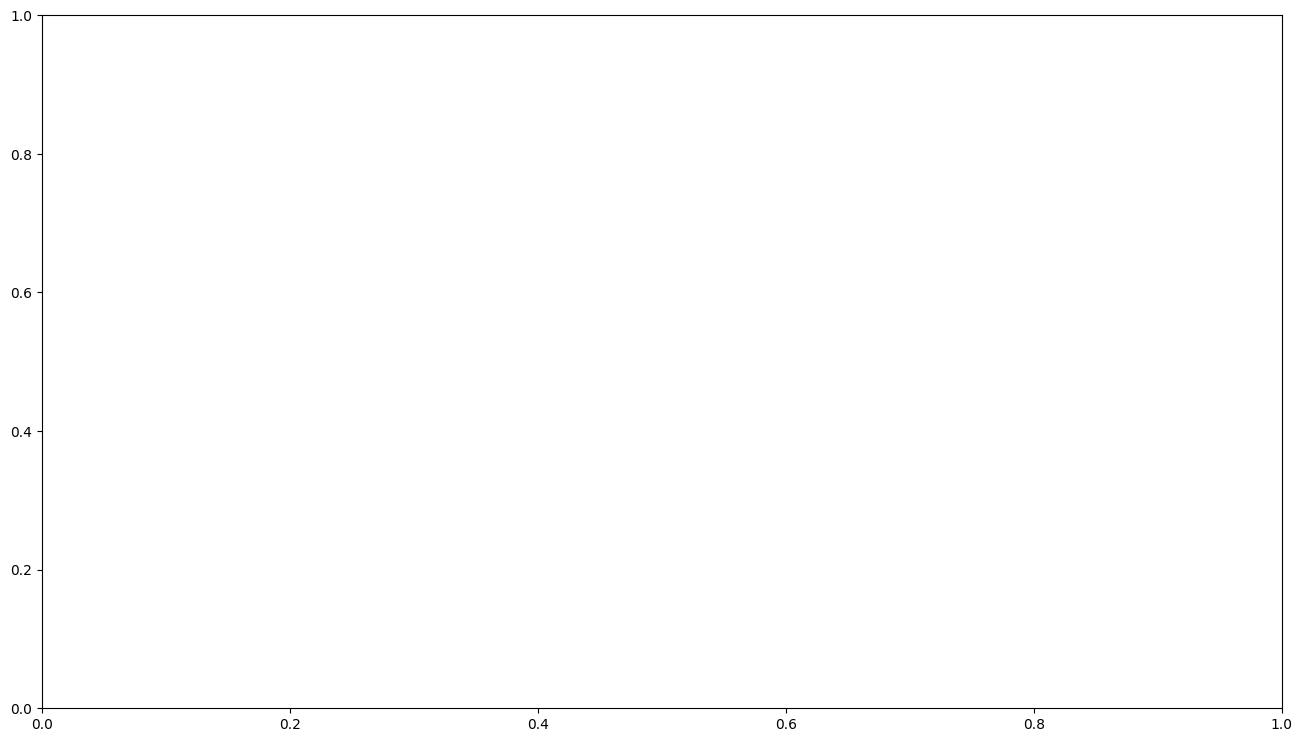

In [10]:
fig, axes = plt.subplots(figsize=(16, 9))

sns.histplot(data=df, x=column_name, kde=True, ax=axes)
axes.set_title(f"Verteilung: {column_name}")

plt.show()

### Korrelationsanalyse

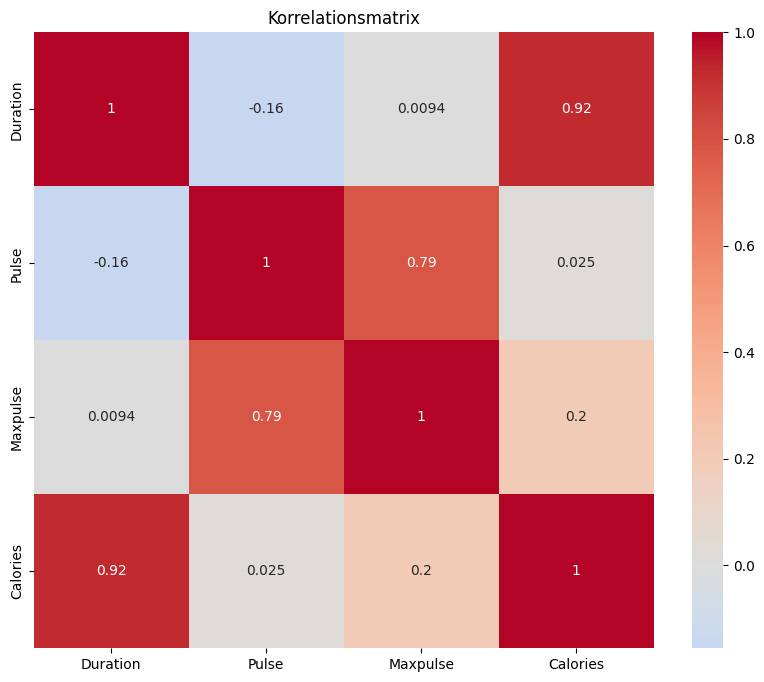

In [6]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Korrelationsmatrix')
plt.show()

### Punktediagramm

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Dauer', y='Kalorien', hue='Trainingsart', palette='Set1')
plt.title('Streudiagramm: Dauer vs Kalorien')
plt.xlabel('Dauer')
plt.ylabel('Kalorien')

plt.show()

NameError: name 'df' is not defined

## Zusammenfassung der Analyse

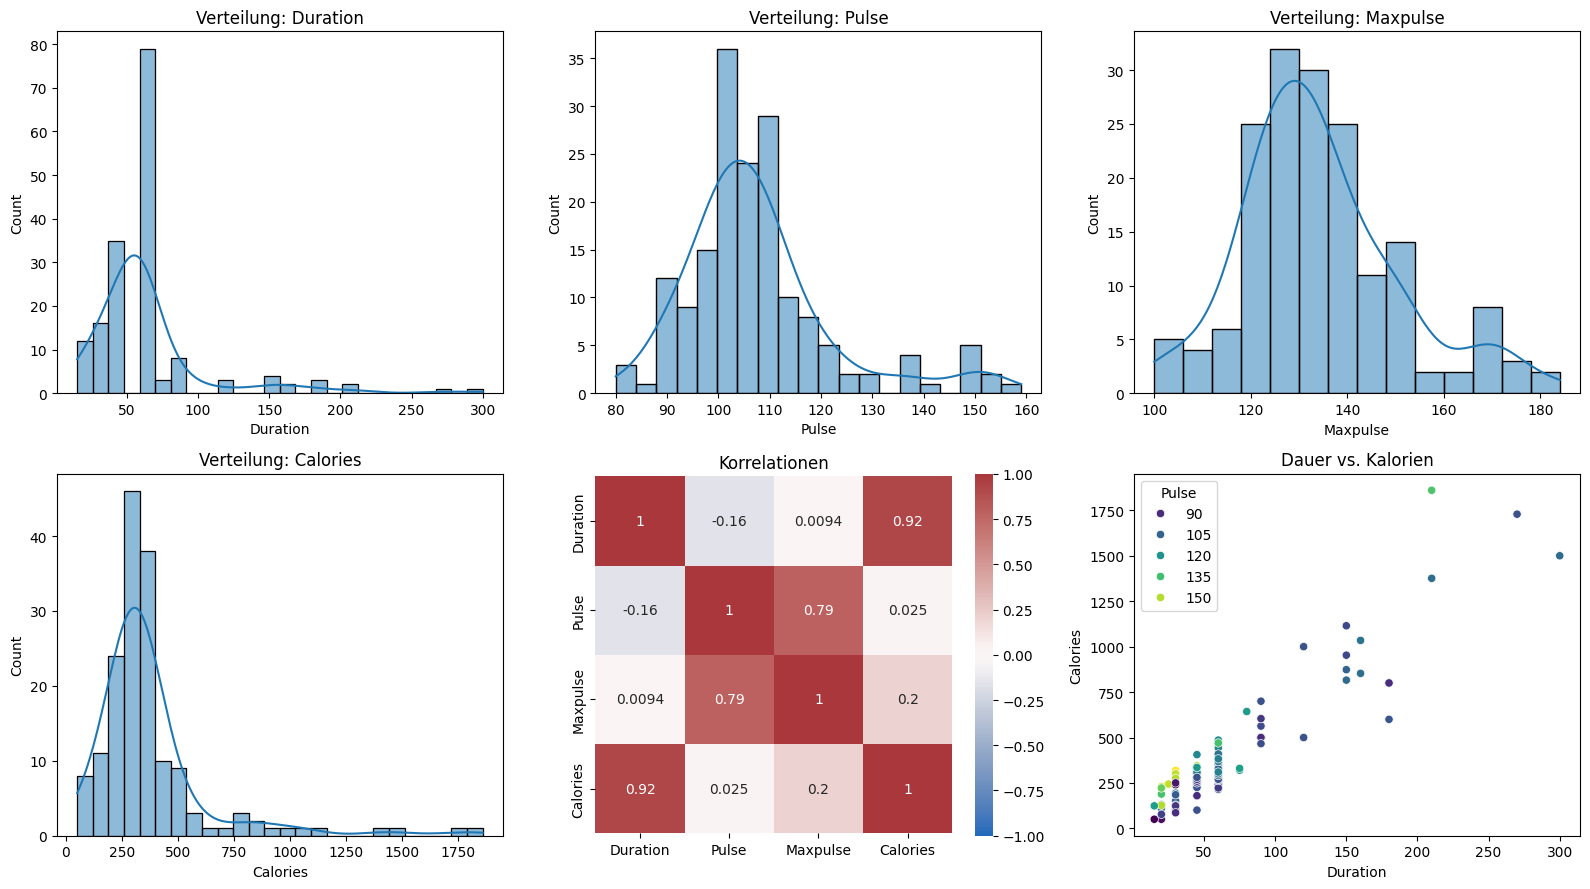

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for axis, column_name in zip(axes[:4], numeric_columns):
    sns.histplot(data=df, x=column_name, kde=True, ax=axis)
    axis.set_title(f"Verteilung: {column_name}")

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[4]
)
axes[4].set_title("Korrelationen")

sns.scatterplot(
    data=df,
    x="Duration",
    y="Calories",
    hue="Pulse",
    palette="viridis",
    ax=axes[5]
)
axes[5].set_title("Dauer vs. Kalorien")

plt.tight_layout()
plt.show()